In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np2

In [2]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================

df = pd.read_csv('../Data/uber_taxi_demand_5years.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

In [3]:
print("Total Pickups   :", df["pickup_count"].sum())
print("Average Pickups :", round(df["pickup_count"].mean(), 2))
print("Median Pickups  :", df["pickup_count"].median())
print("Std Dev         :", round(df["pickup_count"].std(), 2),"\n")

peak_row = df.loc[df["pickup_count"].idxmax()]
print("Peak Demand:", peak_row["pickup_count"])
print("DateTime    :", peak_row["datetime"])
print("Zone        :", peak_row["zone"],"\n")

lowest_row = df.loc[df["pickup_count"].idxmin()]
print("Lowest Demand:", lowest_row["pickup_count"])
print("DateTime     :", lowest_row["datetime"])
print("Zone         :", lowest_row["zone"])

Total Pickups   : 8630596
Average Pickups : 39.39
Median Pickups  : 29.0
Std Dev         : 36.27 

Peak Demand: 571
DateTime    : 2024-12-31 08:00:00
Zone        : Midtown 

Lowest Demand: 0
DateTime     : 2021-01-01 03:00:00
Zone         : Suburb


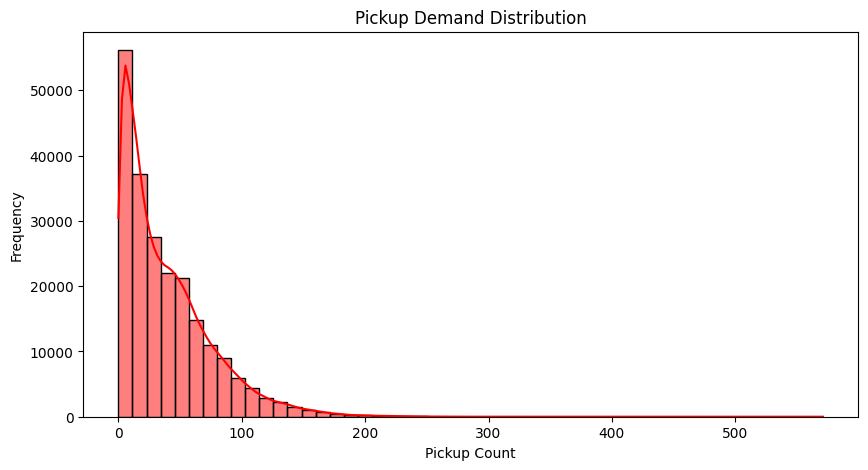

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df["pickup_count"], bins=50, kde=True, color='red', edgecolor='black')
plt.title("Pickup Demand Distribution")
plt.xlabel("Pickup Count")
plt.ylabel("Frequency")
plt.show()

In [5]:
df.set_index('datetime', inplace=True)   

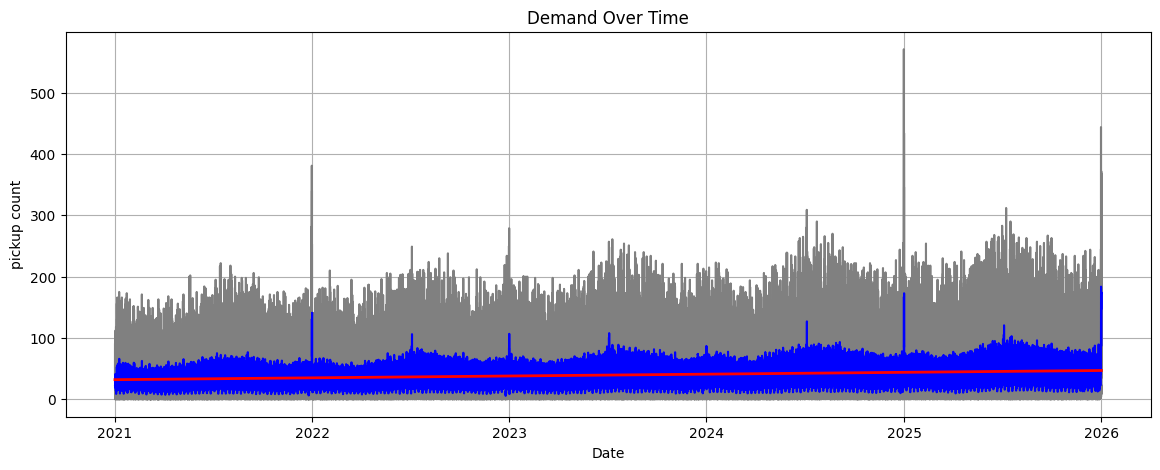

Slope: 0.0001


In [6]:
# Demand Over Time (line plot - full 5 years):
x = np.arange(len(df))
y = df['pickup_count'].values
coeffs = np.polyfit(x, y, deg=1)
trend_line = np.polyval(coeffs, x)

df['SMA_7'] = df['pickup_count'].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(df.index, df['pickup_count'], color='grey')
plt.plot(df['SMA_7'], label='SMA 7-day', color='blue')
plt.plot(df.index, trend_line, label='Trend Line (deg=1)', 
         color='red', linewidth=2)

plt.title("Demand Over Time")
plt.xlabel("Date")
plt.ylabel("pickup count")
plt.grid()
plt.show()

print(f"Slope: {coeffs[0]:.4f}")

D:\Temp\ipykernel_31712\3033864561.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='hour', y='pickup_count', errorbar=None, palette='viridis', legend=False)


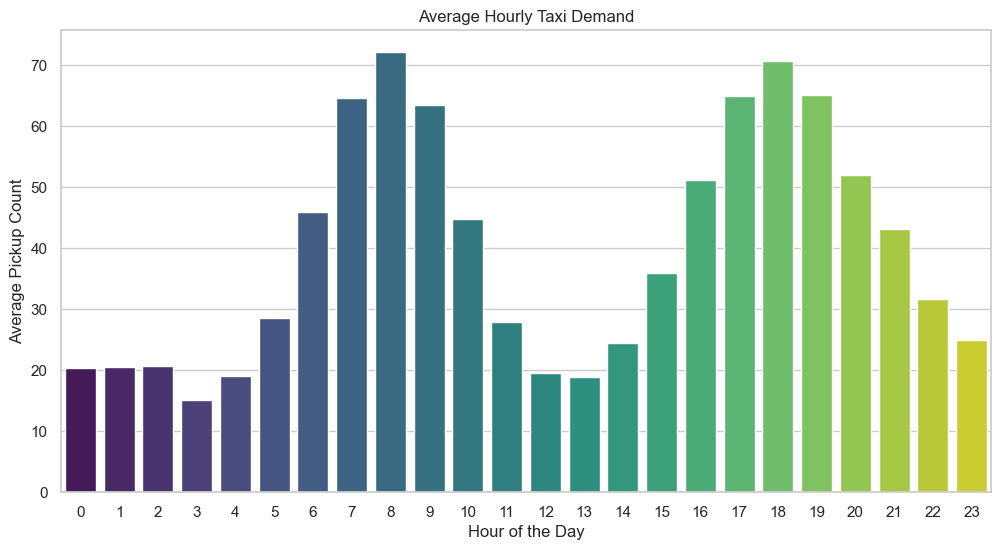

In [7]:
df['hour'] = df.index.hour

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(data=df, x='hour', y='pickup_count', errorbar=None, palette='viridis', legend=False)
plt.title('Average Hourly Taxi Demand')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Pickup Count')
plt.xticks(range(24))

plt.show()

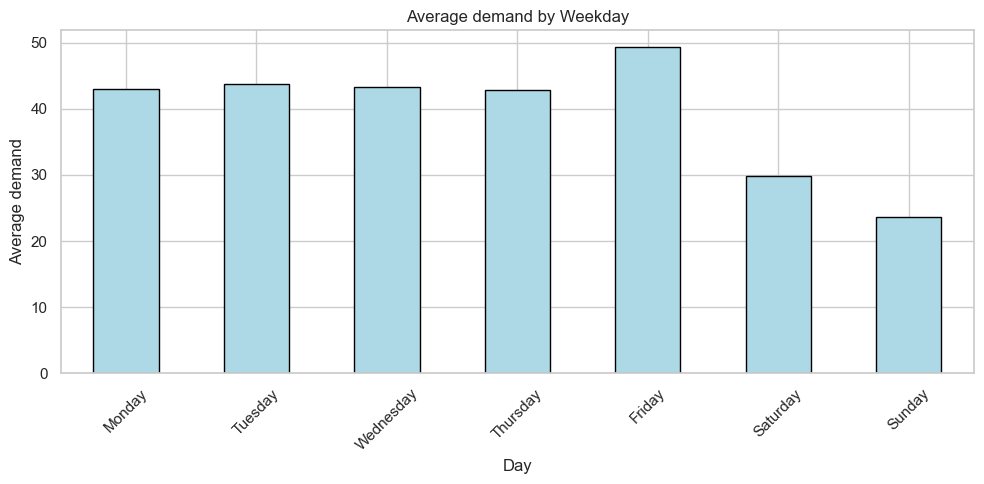

weekday
Monday       43.017082
Tuesday      43.667944
Wednesday    43.341475
Thursday     42.800481
Friday       49.379853
Saturday     29.832280
Sunday       23.686686
Name: pickup_count, dtype: float64


In [8]:
df['weekday'] = df.index.day_name()

weekday_order = ['Monday','Tuesday','Wednesday',
                 'Thursday','Friday','Saturday','Sunday']

weekday_avg = df.groupby('weekday')['pickup_count'].mean()
weekday_avg = weekday_avg.reindex(weekday_order)

# Plot
plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Average demand by Weekday')
plt.xlabel('Day')
plt.ylabel('Average demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekday_avg)

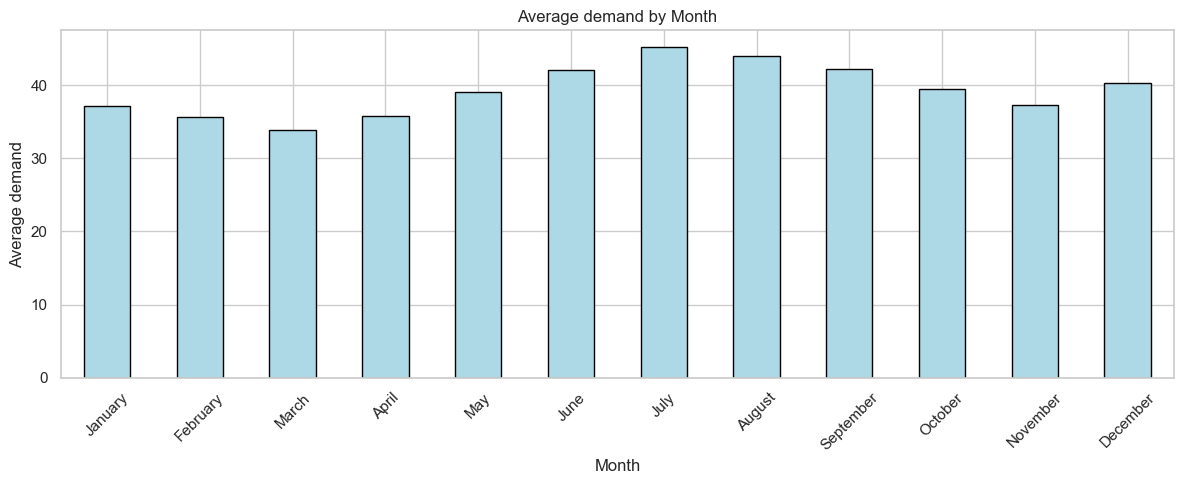

month
January      37.157151
February     35.639953
March        33.921452
April        35.847556
May          39.090323
June         42.068889
July         45.240269
August       43.943763
September    42.249278
October      39.545968
November     37.245389
December     40.357419
Name: pickup_count, dtype: float64


In [9]:
df['month'] = df.index.month_name()

month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

month_avg = df.groupby('month')['pickup_count'].mean()
month_avg = month_avg.reindex(month_order)

plt.figure(figsize=(12,5))
month_avg.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Average demand by Month')
plt.xlabel('Month')
plt.ylabel('Average demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(month_avg)

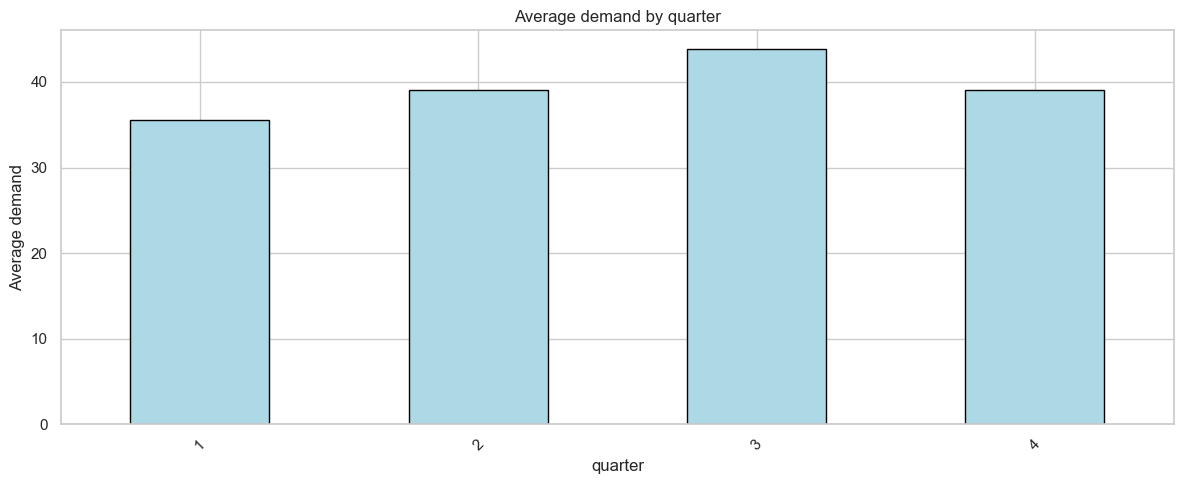

quarter
1    35.570769
2    39.003223
3    43.828080
4    39.069203
Name: pickup_count, dtype: float64


In [10]:
df['quarter'] = df.index.quarter

quarter = df.groupby('quarter')['pickup_count'].mean()

plt.figure(figsize=(12,5))
quarter.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Average demand by quarter')
plt.xlabel('quarter')
plt.ylabel('Average demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(quarter)

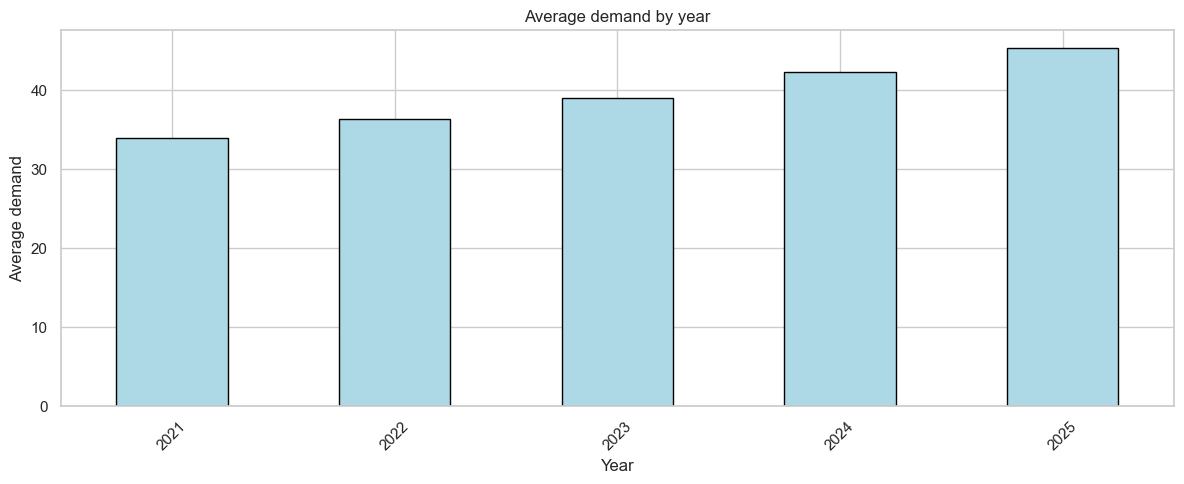

year
2021    33.916416
2022    36.346119
2023    39.079886
2024    42.267509
2025    45.319840
Name: pickup_count, dtype: float64


In [11]:
df['year'] = df.index.year

year = df.groupby('year')['pickup_count'].mean()

plt.figure(figsize=(12,5))
year.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Average demand by year')
plt.xlabel('Year')
plt.ylabel('Average demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(year)